# Лабораторная работа №3

## Деревья решений в задачах классификации и регрессии. ROC-кривая

Импортируем библиотеку:

In [104]:
import pandas as pd

### Регрессия

Загружаем датасет для задачи регрессии:

In [105]:
df_reg = pd.read_csv("data/StudentsPerformance_processed.csv")

Разделяем данные на матрицу признаков и вектор целевой переменной:

In [106]:
X_reg = df_reg.drop("math score", axis=1)
y_reg = df_reg["math score"]

print(X_reg.shape)
print(y_reg.shape)

(1000, 15)
(1000,)


Разделаем данные на обущающую и тестовую выборки в отношении 80 на 20:

In [107]:
from sklearn.model_selection import train_test_split

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

Импортируем модель решающего дерева без гиперпараметров и обучаем её на обучающей выборке:

In [108]:
from sklearn.tree import DecisionTreeRegressor

dt_regressor_base = DecisionTreeRegressor()
dt_regressor_base.fit(X_reg_train, y_reg_train)

,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree wi

Выведем значения квадратичной ошибки на обучающей и тестовой выборке чтобы проверить, переобучилась ли модель:

In [109]:
from sklearn.metrics import mean_squared_error

y_train_pred = dt_regressor_base.predict(X_reg_train)
rmse_train = mean_squared_error(y_reg_train, y_train_pred)

y_test_pred = dt_regressor_model.predict(X_reg_test)
rmse_test = mean_squared_error(y_reg_test, y_test_pred)

print("Квадратичная ошибка на обущающей выборке:", rmse_train)
print("Квадратичная ошибка на тестовой выборке:", rmse_test)

Квадратичная ошибка на обущающей выборке: 0.0
Квадратичная ошибка на тестовой выборке: 164.26


Ожидаемо, модель переобучилась (ошибка на обущающей 0). Попробуем исправить это с помощью установки гиперпараметров:

In [133]:
dt_regressor_param = DecisionTreeRegressor(max_depth=6, min_samples_leaf=12, min_samples_split=3)
dt_regressor_param.fit(X_reg_train, y_reg_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",12
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with

Построим получившееся дерево

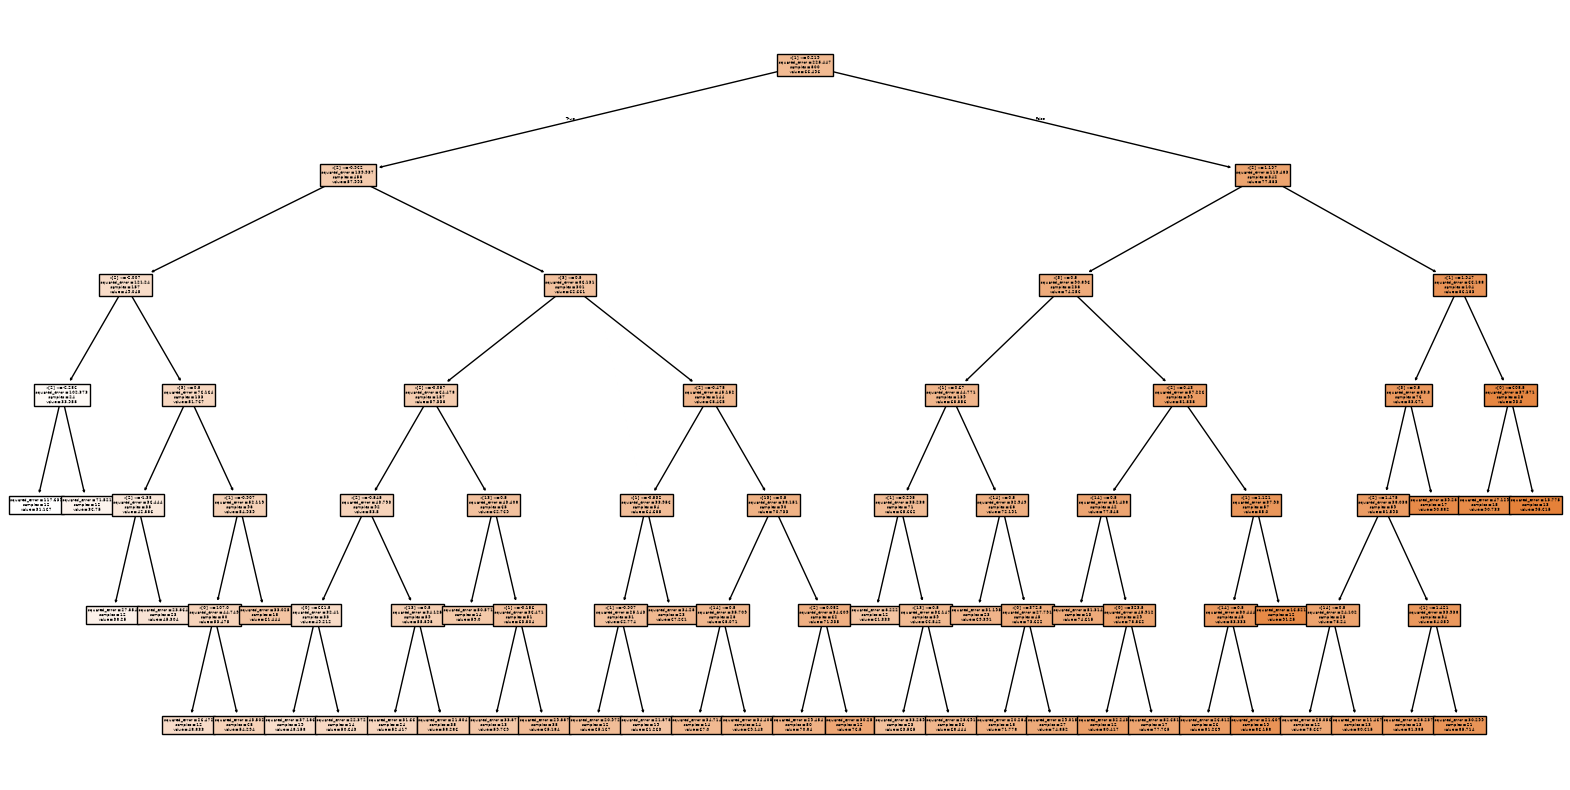

In [134]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(dt_regressor_param, filled=True)
plt.show()

Снова проверим среднеквадратичную ошибку:

In [135]:
y_train_pred = dt_regressor_param.predict(X_reg_train)
rmse_train = mean_squared_error(y_reg_train, y_train_pred)

y_test_pred = dt_regressor_param.predict(X_reg_test)
rmse_test = mean_squared_error(y_reg_test, y_test_pred)

print("Квадратичная ошибка на обущающей выборке:", rmse_train)
print("Квадратичная ошибка на тестовой выборке:", rmse_test)

Квадратичная ошибка на обущающей выборке: 32.66781219763346
Квадратичная ошибка на тестовой выборке: 151.6827725840026


In [136]:
from sklearn.metrics import r2_score

print(r2_score(y_reg_test, y_test_pred))

0.37665911921832884


### Классификация

Загружаем датасет для классификации:

In [138]:
df_clf = pd.read_csv("data/StudentsPerformance_clf.csv")

Разделяем данные на матрицу признаков и вектор целевой переменной:

In [139]:
X_clf = df_clf.drop("is_passed", axis=1)
y_clf = df_clf.is_passed

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

Импортируем модель решающего дерева с гиперпараметром *max_depth* и обучаем её на обучающей выборке:

In [140]:
from sklearn.tree import DecisionTreeClassifier

dt_classifier = DecisionTreeClassifier(max_depth=6)
dt_classifier.fit(X_clf_train, y_clf_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples 

In [141]:
y_clf_pred_test = dt_classifier.predict(X_clf_test)

Оцениваем точность обученной модели:

In [142]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_clf_test, y_clf_pred_test)
print(accuracy)

0.705


Считаем основные метрики классификации для более полной оценки качества обучения:

In [144]:
from sklearn.metrics import recall_score, precision_score, f1_score

recall = recall_score(y_clf_test, y_clf_pred_test)
print("Recall:", recall)
precision = precision_score(y_clf_test, y_clf_pred_test)
print("Precision:", recall)
f1 = f1_score(y_clf_test, y_clf_pred_test)
print("F1:", f1)

Recall: 0.9130434782608695
Precision: 0.9130434782608695
F1: 0.4158415841584158


Строим ROC-кривую и считаем значение под площадью - AUC:

In [157]:
from sklearn.metrics import roc_curve, auc

y_proba = dt_classifier.predict_proba(X_clf_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_clf_test, y_proba)
roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

AUC: 0.8102431834929992


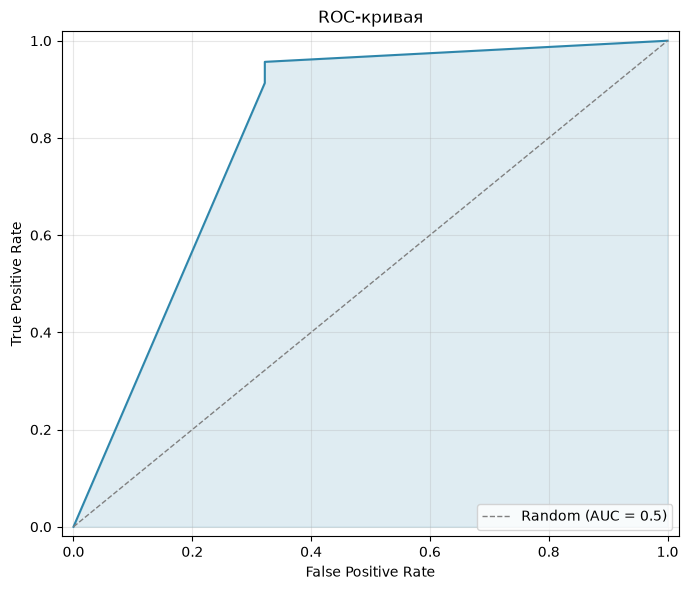

In [162]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr, tpr, color="#2E86AB")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1, label="Random (AUC = 0.5)")

ax.fill_between(fpr, tpr, alpha=0.15, color="#2E86AB")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC-кривая")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.grid(alpha=0.3)
ax.legend(loc="lower right", frameon=True)
plt.tight_layout()
plt.show()

Кривая оказалась значительно выше диагонали, что говорит о довольно хорошей работе модели по решению задачи классификации на наборе данных.